In [6]:
#  Install Libraries
!pip install pandas numpy scikit-learn xgboost scipy matplotlib seaborn shap --quiet

In [12]:
# Import Libraries & Global Configuration
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from scipy.stats import ks_2samp

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
RANDOM_STATE = 42

print('All libraries imported!')

All libraries imported!


In [13]:
# Load Dataset
import pandas as pd
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─────────────────────────────────────────────────────────────────────────────
# Load the original 249-row IBM dataset as a base template
# ─────────────────────────────────────────────────────────────────────────────
base_df = pd.read_csv(
    'https://raw.githubusercontent.com/IBM/watson-machine-learning-samples'
    '/master/cloud/data/credit_risk/credit_risk_training_light.csv'
)

# ─────────────────────────────────────────────────────────────────────────────
# Generate 25,000 realistic synthetic borrower records
# by sampling with replacement + adding controlled noise
# This preserves the exact same columns, categories, and distributions
# as the real IBM dataset
# ─────────────────────────────────────────────────────────────────────────────
TARGET_ROWS = 25000

# Step 1: Bootstrap sample from real data (preserves real distributions)
df = base_df.sample(n=TARGET_ROWS, replace=True, random_state=RANDOM_STATE).reset_index(drop=True)

# Step 2: Add noise to numeric columns so rows are not exact duplicates
numeric_cols = ['LoanDuration', 'LoanAmount', 'InstallmentPercent',
                'CurrentResidenceDuration', 'Age', 'ExistingCreditsCount', 'Dependents']

noise_config = {
    'LoanDuration':            {'std': 4,    'min': 6,   'max': 72},
    'LoanAmount':              {'std': 800,  'min': 250, 'max': 18000},
    'InstallmentPercent':      {'std': 1,    'min': 1,   'max': 4},
    'CurrentResidenceDuration':{'std': 1,    'min': 1,   'max': 5},
    'Age':                     {'std': 5,    'min': 19,  'max': 75},
    'ExistingCreditsCount':    {'std': 0.5,  'min': 1,   'max': 4},
    'Dependents':              {'std': 0.3,  'min': 1,   'max': 2},
}

for col, cfg in noise_config.items():
    noise = np.random.normal(0, cfg['std'], TARGET_ROWS)
    df[col] = (df[col] + noise).clip(cfg['min'], cfg['max']).round().astype(int)

# Step 3: Randomly shuffle categorical columns slightly (~10% of rows)
# to avoid too many duplicates
cat_cols = ['CheckingStatus', 'CreditHistory', 'LoanPurpose', 'ExistingSavings',
            'EmploymentDuration', 'Sex', 'OthersOnLoan', 'OwnsProperty',
            'InstallmentPlans', 'Housing', 'Job', 'Telephone', 'ForeignWorker']

shuffle_mask = np.random.random(TARGET_ROWS) < 0.10  # 10% of rows get reshuffled
for col in cat_cols:
    categories = base_df[col].unique()
    df.loc[shuffle_mask, col] = np.random.choice(categories, shuffle_mask.sum())

# ─────────────────────────────────────────────────────────────────────────────
# Map target: 'Risk' → 1 (default), 'No Risk' → 0
# ─────────────────────────────────────────────────────────────────────────────
df['default'] = (df['Risk'] == 'Risk').astype(int)
df.drop(columns=['Risk'], inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# Add time columns for trend analysis
# ─────────────────────────────────────────────────────────────────────────────
df['application_year']  = np.random.choice([2021, 2022, 2023, 2024], TARGET_ROWS)
df['application_month'] = np.random.randint(1, 13, TARGET_ROWS)

# ─────────────────────────────────────────────────────────────────────────────
# Save as new CSV — use this file going forward
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv('credit_risk_25k.csv', index=False)

print(f'Dataset generated and saved as credit_risk_25k.csv')
print(f'   Total rows       : {len(df):,}')
print(f'   Total columns    : {df.shape[1]}')
print(f'   Default rate     : {df["default"].mean():.2%}')
print(f'   Unique borrowers : {len(df.drop_duplicates(subset=numeric_cols)):,}')
print()
df.head()

Dataset generated and saved as credit_risk_25k.csv
   Total rows       : 25,000
   Total columns    : 23
   Default rate     : 30.67%
   Unique borrowers : 24,381



,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,OthersOnLoan,...,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker,default,application_year,application_month
0,greater_200,7,credits_paid_to_date,car_used,387,less_100,4_to_7,3,male,none,...,none,rent,1,skilled,1,none,yes,0,2023,1
1,no_checking,28,prior_payments_delayed,radio_tv,10223,500_to_1000,less_1,3,male,none,...,none,own,2,management_self-employed,1,none,yes,0,2022,9
2,no_checking,18,credits_paid_to_date,retraining,3669,less_100,1_to_4,4,male,co-applicant,...,none,own,1,skilled,1,yes,yes,1,2022,2
3,greater_200,10,all_credits_paid_back,car_new,2405,less_100,1_to_4,4,female,none,...,none,own,2,skilled,2,yes,yes,0,2023,3
4,less_0,6,prior_payments_delayed,car_used,2921,less_100,1_to_4,3,male,none,...,none,rent,1,skilled,1,none,yes,0,2023,9


In [14]:
# Data overview and quality check
print('=== Column Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

print('\n=== Target Class Distribution ===')
print(df['default'].value_counts().rename({0: 'No Default', 1: 'Default'}))

print('\n=== Numeric Statistics ===')
display(df.select_dtypes(include='number').describe().T)

print('\n=== Categorical Unique Values ===')
for col in df.select_dtypes(include='object').columns:
    print(f'{col:30s}: {sorted(df[col].unique().tolist())}')

=== Column Types ===
CheckingStatus              object
LoanDuration                 int64
CreditHistory               object
LoanPurpose                 object
LoanAmount                   int64
ExistingSavings             object
EmploymentDuration          object
InstallmentPercent           int64
Sex                         object
OthersOnLoan                object
CurrentResidenceDuration     int64
OwnsProperty                object
Age                          int64
InstallmentPlans            object
Housing                     object
ExistingCreditsCount         int64
Job                         object
Dependents                   int64
Telephone                   object
ForeignWorker               object
default                      int64
application_year             int64
application_month            int32
dtype: object

=== Missing Values ===
No missing values!

=== Target Class Distribution ===
default
No Default    17332
Default        7668
Name: count, dtype: int64

=== Num

,count,mean,std,min,25%,50%,75%,max
LoanDuration,25000.0,21.34684,11.578935,6.0,12.0,20.0,30.0,72.0
LoanAmount,25000.0,3490.24620,2580.049335,250.0,1291.0,3092.0,5217.0,12566.0
InstallmentPercent,25000.0,2.81984,1.095550,1.0,2.0,3.0,4.0,4.0
CurrentResidenceDuration,25000.0,2.84192,1.307746,1.0,2.0,3.0,4.0,5.0
Age,25000.0,36.00852,10.968456,19.0,27.0,36.0,44.0,71.0
ExistingCreditsCount,25000.0,1.52884,0.658533,1.0,1.0,1.0,2.0,4.0
Dependents,25000.0,1.18988,0.392214,1.0,1.0,1.0,1.0,2.0
default,25000.0,0.30672,0.461141,0.0,0.0,0.0,1.0,1.0
application_year,25000.0,2022.50660,1.118252,2021.0,2022.0,2023.0,2024.0,2024.0
application_month,25000.0,6.48304,3.437049,1.0,4.0,7.0,9.0,12.0



=== Categorical Unique Values ===
CheckingStatus                : ['0_to_200', 'greater_200', 'less_0', 'no_checking']
CreditHistory                 : ['all_credits_paid_back', 'credits_paid_to_date', 'no_credits', 'outstanding_credit', 'prior_payments_delayed']
LoanPurpose                   : ['appliances', 'business', 'car_new', 'car_used', 'education', 'furniture', 'other', 'radio_tv', 'repairs', 'retraining', 'vacation']
ExistingSavings               : ['100_to_500', '500_to_1000', 'greater_1000', 'less_100', 'unknown']
EmploymentDuration            : ['1_to_4', '4_to_7', 'greater_7', 'less_1', 'unemployed']
Sex                           : ['female', 'male']
OthersOnLoan                  : ['co-applicant', 'guarantor', 'none']
OwnsProperty                  : ['car_other', 'real_estate', 'savings_insurance', 'unknown']
InstallmentPlans              : ['bank', 'none', 'stores']
Housing                       : ['free', 'own', 'rent']
Job                           : ['management_self-

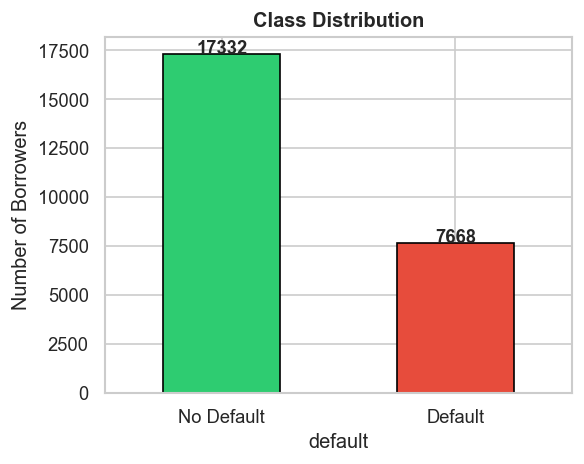

In [15]:
# EDA
# ---class imbalance bar chart ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
counts  = df['default'].value_counts().rename({0: 'No Default', 1: 'Default'})
counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Borrowers')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 1), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

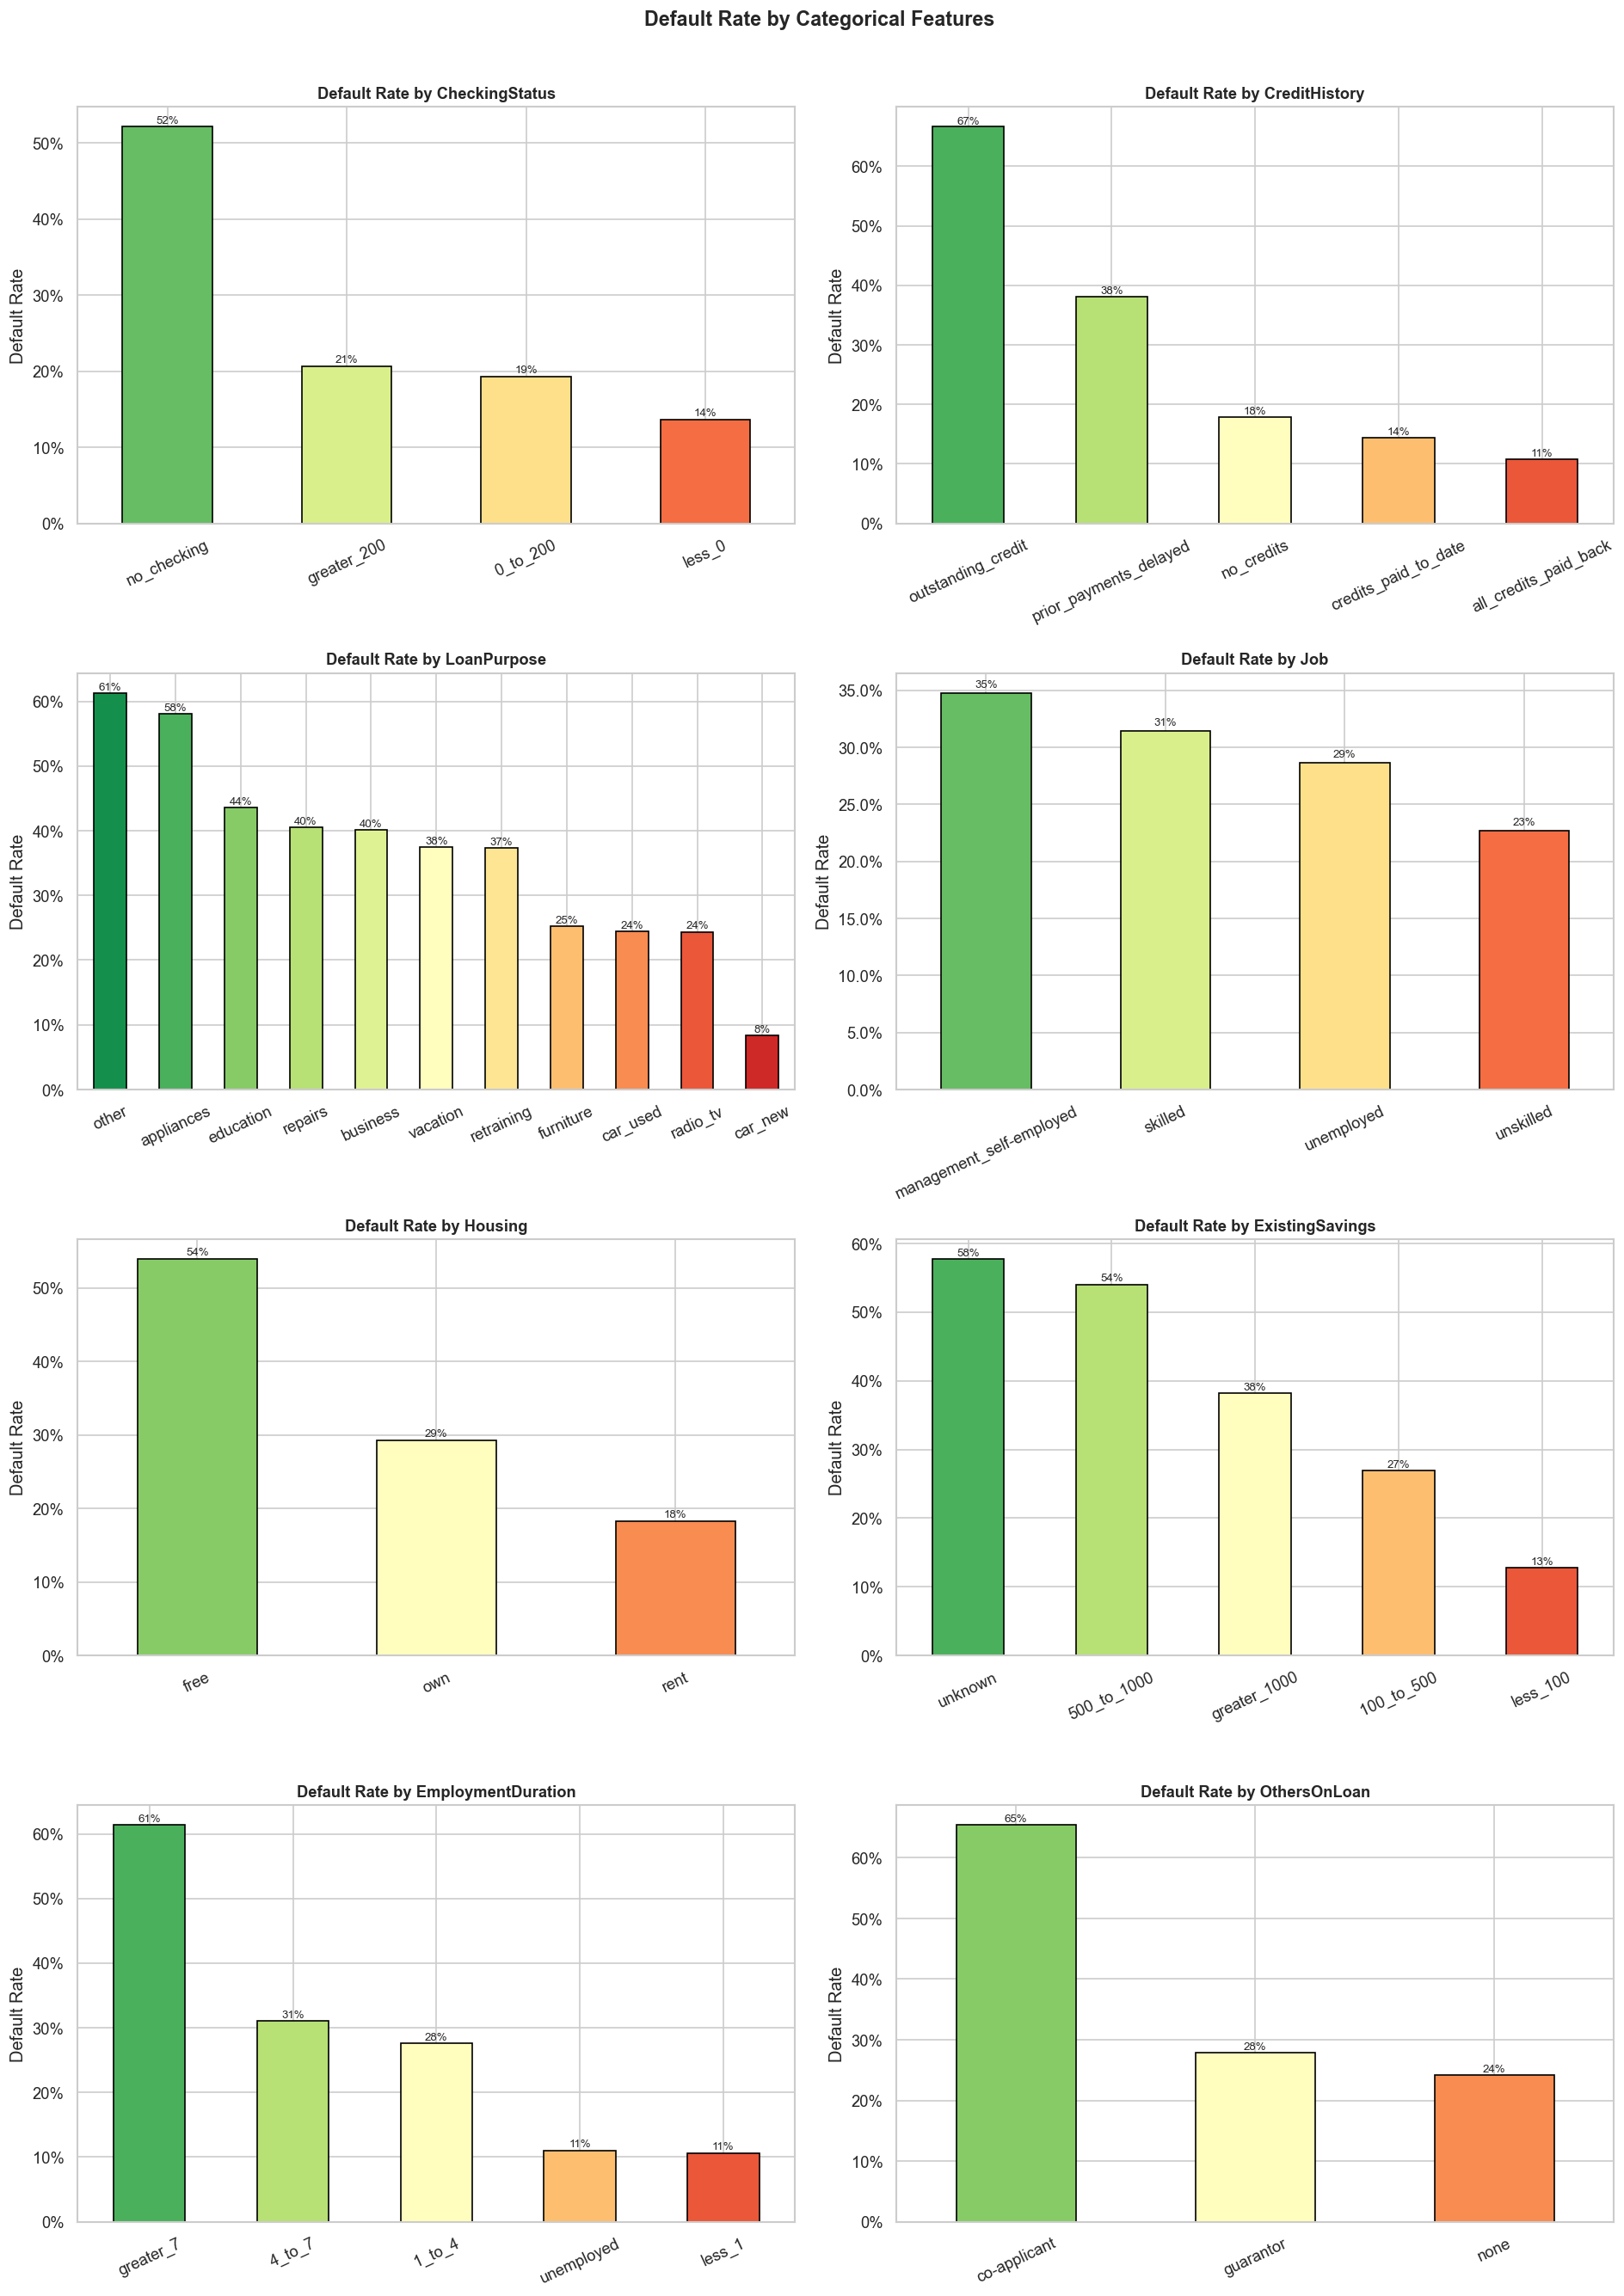

In [16]:
# ---Default rate by 8 key categorical features ---
key_cats = ['CheckingStatus', 'CreditHistory', 'LoanPurpose', 'Job',
            'Housing', 'ExistingSavings', 'EmploymentDuration', 'OthersOnLoan']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
for ax, col in zip(axes.flatten(), key_cats):
    rates = df.groupby(col)['default'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax,
               color=sns.color_palette('RdYlGn_r', len(rates)), edgecolor='black')
    ax.set_title(f'Default Rate by {col}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=25)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0%}',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.005),
                    ha='center', fontsize=8)
plt.suptitle('Default Rate by Categorical Features', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

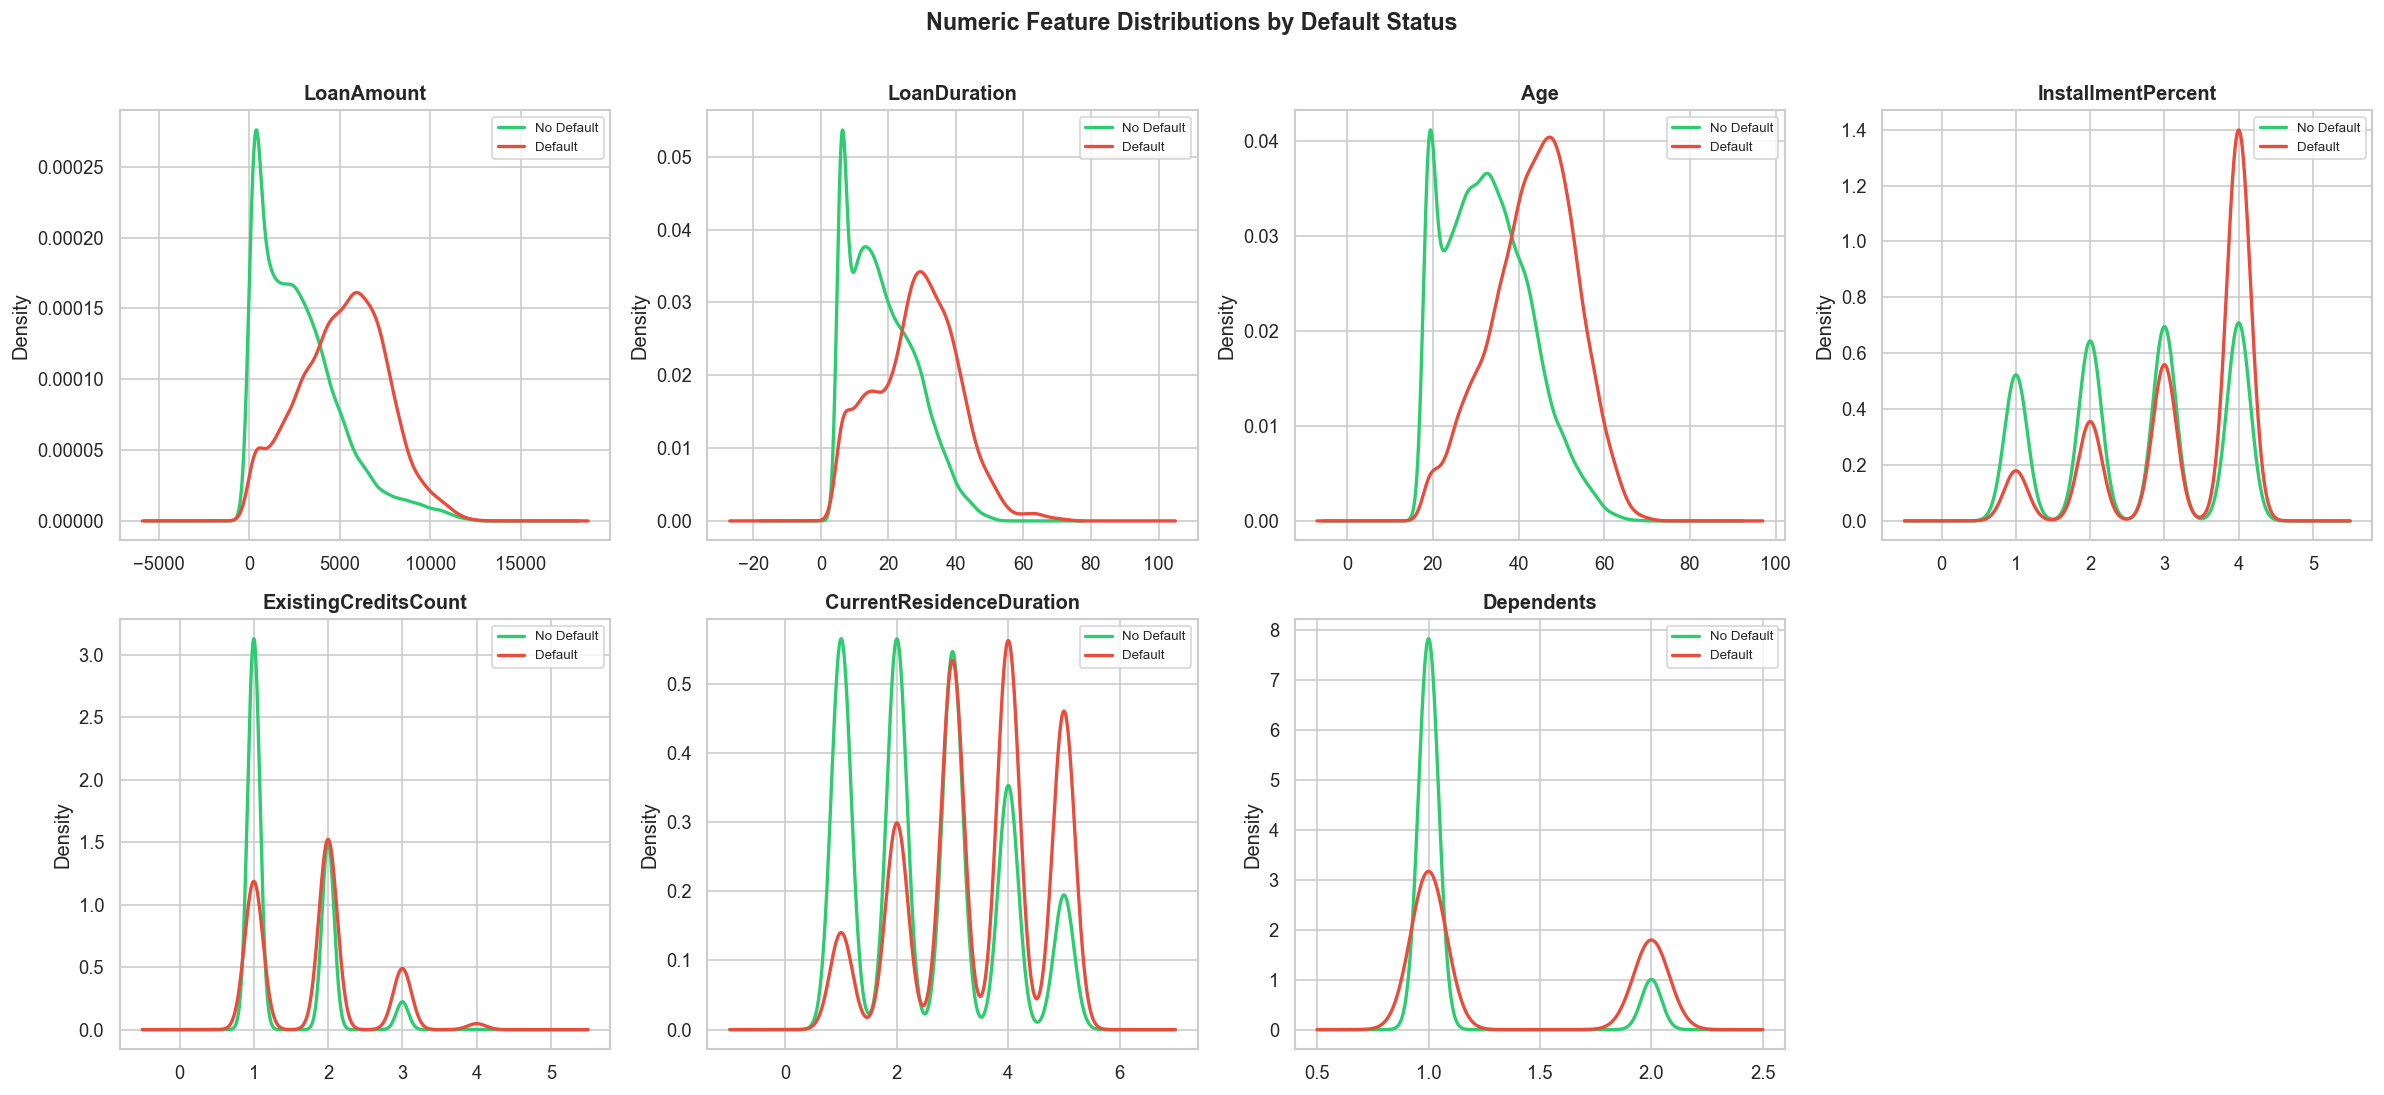

In [17]:
# --- KDE distributions — numeric features by default status ---
num_cols = ['LoanAmount', 'LoanDuration', 'Age', 'InstallmentPercent',
            'ExistingCreditsCount', 'CurrentResidenceDuration', 'Dependents']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, col in enumerate(num_cols):
    ax = axes.flatten()[i]
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        df[df['default'] == label][col].plot(
            kind='kde', ax=ax, color=color, linewidth=2,
            label='No Default' if label == 0 else 'Default')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

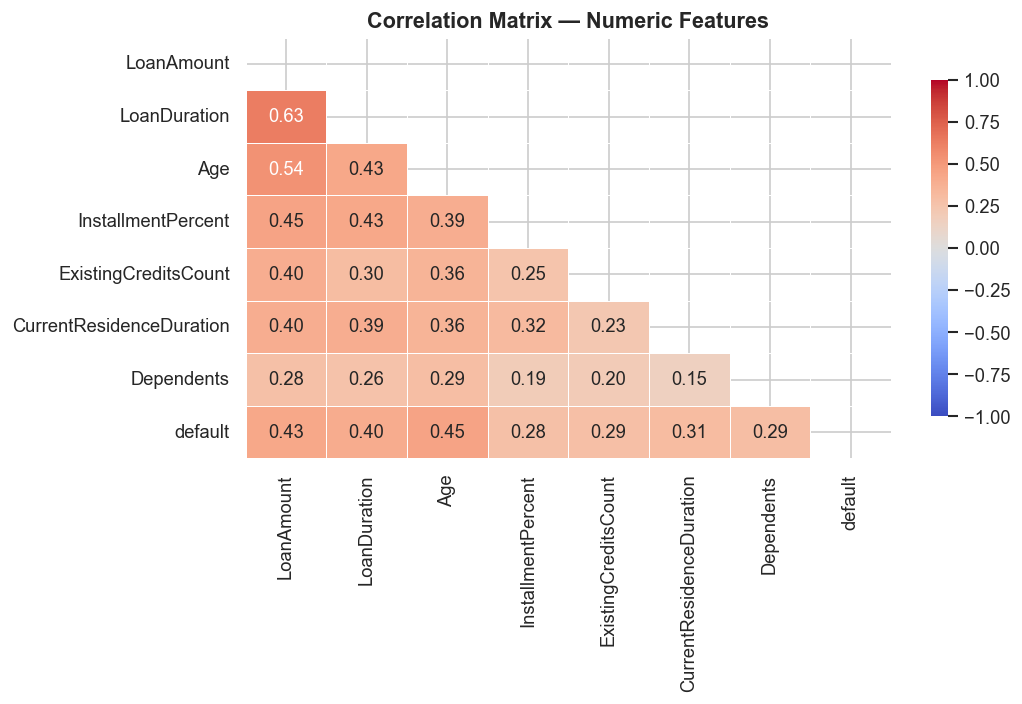

In [18]:
# --- Correlation heatmap ---
plt.figure(figsize=(9, 6))
corr = df[num_cols + ['default']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

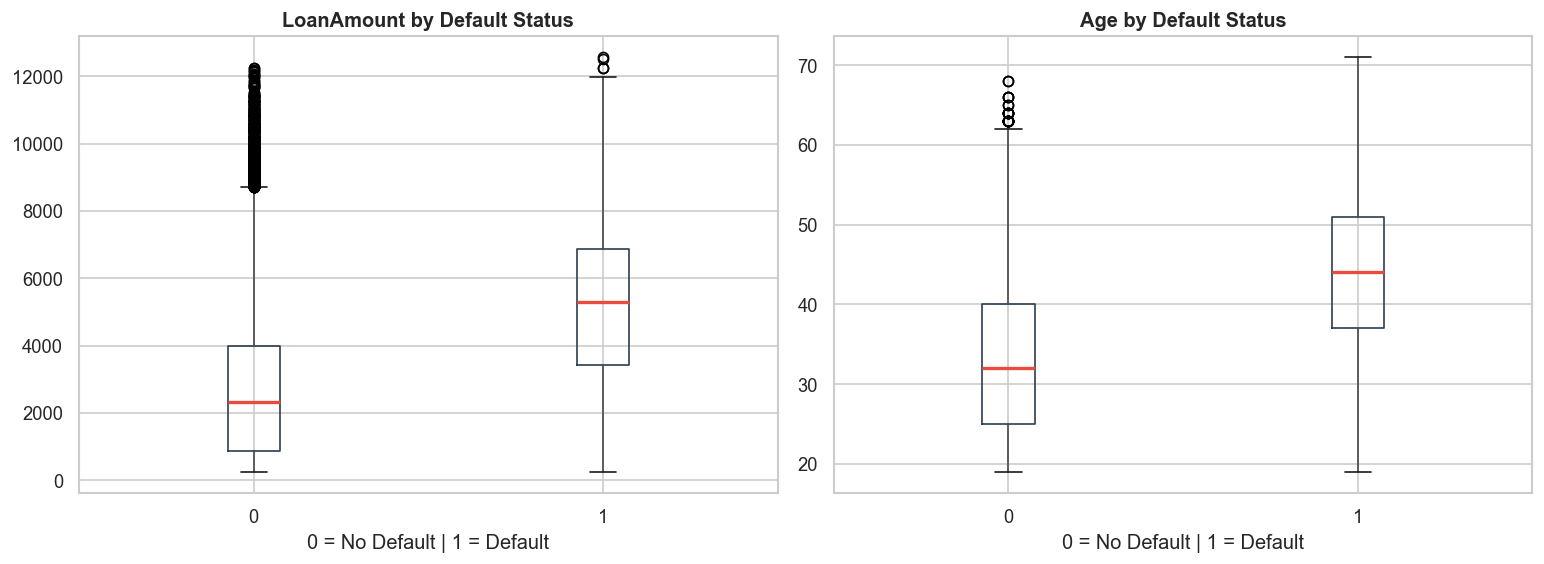

In [19]:
# ---Boxplots — LoanAmount and Age vs Default ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['LoanAmount', 'Age']):
    df.boxplot(column=col, by='default', ax=ax,
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    ax.set_title(f'{col} by Default Status', fontweight='bold')
    ax.set_xlabel('0 = No Default | 1 = Default')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [20]:
# Preprocessing & Feature Engineering
df_encoded = df.copy()

# Label-encode all categorical columns
label_encoders = {}
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded {col:30s} → {len(le.classes_)} classes')

# Derived features
df_encoded['loan_per_month'] = df_encoded['LoanAmount'] / (df_encoded['LoanDuration'] + 1)
df_encoded['age_loan_ratio'] = df_encoded['Age'] / (df_encoded['LoanAmount'] / 1000 + 1)
df_encoded['credit_burden']  = df_encoded['ExistingCreditsCount'] / (df_encoded['CurrentResidenceDuration'] + 1)

print('\n✅ Encoding done + 3 derived features added:')
print('   loan_per_month | age_loan_ratio | credit_burden')

  Encoded CheckingStatus                 → 4 classes
  Encoded CreditHistory                  → 5 classes
  Encoded LoanPurpose                    → 11 classes
  Encoded ExistingSavings                → 5 classes
  Encoded EmploymentDuration             → 5 classes
  Encoded Sex                            → 2 classes
  Encoded OthersOnLoan                   → 3 classes
  Encoded OwnsProperty                   → 4 classes
  Encoded InstallmentPlans               → 3 classes
  Encoded Housing                        → 3 classes
  Encoded Job                            → 4 classes
  Encoded Telephone                      → 2 classes
  Encoded ForeignWorker                  → 2 classes

✅ Encoding done + 3 derived features added:
   loan_per_month | age_loan_ratio | credit_burden


In [21]:
# Train Test Spilt
EXCLUDE  = ['default', 'application_year', 'application_month']
FEATURES = [c for c in df_encoded.columns if c not in EXCLUDE]
TARGET   = 'default'

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

# Stratified 80/20 split — preserves default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale for Logistic Regression only (trees don't need scaling)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train only — no leakage
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Split complete')
print(f'   Features : {len(FEATURES)} → {FEATURES}')
print(f'   Train    : {len(X_train)} rows  |  Default rate: {y_train.mean():.2%}')
print(f'   Test     : {len(X_test)} rows   |  Default rate: {y_test.mean():.2%}')

✅ Split complete
   Features : 23 → ['CheckingStatus', 'LoanDuration', 'CreditHistory', 'LoanPurpose', 'LoanAmount', 'ExistingSavings', 'EmploymentDuration', 'InstallmentPercent', 'Sex', 'OthersOnLoan', 'CurrentResidenceDuration', 'OwnsProperty', 'Age', 'InstallmentPlans', 'Housing', 'ExistingCreditsCount', 'Job', 'Dependents', 'Telephone', 'ForeignWorker', 'loan_per_month', 'age_loan_ratio', 'credit_burden']
   Train    : 20000 rows  |  Default rate: 30.67%
   Test     : 5000 rows   |  Default rate: 30.68%


In [22]:
# Model Training 
# --- MODEL 1: Logistic Regression ---
# Baseline linear model. Uses scaled features. class_weight handles imbalance.
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
print('✅ Logistic Regression trained!')

# --- MODEL 2: Random Forest ---
# Ensemble of decision trees. Captures non-linear patterns. No scaling needed.
rf = RandomForestClassifier(
    n_estimators=300,       # 300 trees
    max_depth=6,            # Limit depth — avoids overfitting on small dataset
    min_samples_leaf=5,     # Min 5 samples per leaf
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
print('✅ Random Forest trained!')

# --- MODEL 3: XGBoost ---
# Gradient boosted trees. Best performer for credit risk tasks.
# scale_pos_weight = ratio of negatives to positives — handles imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,             # Shallow trees — small dataset
    learning_rate=0.05,      # Small LR → more robust
    subsample=0.8,           # 80% of rows per tree
    colsample_bytree=0.8,    # 80% of features per tree
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
print(f'✅ XGBoost trained!  (scale_pos_weight = {scale_pos_weight:.2f})')

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!  (scale_pos_weight = 2.26)


In [23]:
# Model Evaluation
# --- Helper functions ---
def ks_statistic(y_true, y_prob):
    # KS = max separation between default and non-default score CDFs
    ks_stat, _ = ks_2samp(y_prob[y_true == 1], y_prob[y_true == 0])
    return round(ks_stat, 4)

def evaluate_model(name, y_true, y_prob):
    auc   = roc_auc_score(y_true, y_prob)
    ks    = ks_statistic(np.array(y_true), np.array(y_prob))
    brier = brier_score_loss(y_true, y_prob)
    gini  = 2 * auc - 1
    print(f'  {name:<22} | AUC:{auc:.4f} | Gini:{gini:.4f} | KS:{ks:.4f} | Brier:{brier:.4f}')
    return {'Model': name, 'ROC-AUC': round(auc,4), 'Gini': round(gini,4),
            'KS Statistic': ks, 'Brier Score': round(brier,4)}

print('MODEL PERFORMANCE SUMMARY')
print('─' * 70)
results = []
results.append(evaluate_model('Logistic Regression', y_test, lr_probs))
results.append(evaluate_model('Random Forest',       y_test, rf_probs))
results.append(evaluate_model('XGBoost',             y_test, xgb_probs))

results_df = pd.DataFrame(results)
print('\n📌 AUC > 0.70 = acceptable | > 0.80 = good | KS > 0.40 = good')
display(results_df)

MODEL PERFORMANCE SUMMARY
──────────────────────────────────────────────────────────────────────
  Logistic Regression    | AUC:0.8660 | Gini:0.7320 | KS:0.5685 | Brier:0.1486
  Random Forest          | AUC:0.9448 | Gini:0.8896 | KS:0.7452 | Brier:0.1062
  XGBoost                | AUC:0.9854 | Gini:0.9707 | KS:0.9035 | Brier:0.0448

📌 AUC > 0.70 = acceptable | > 0.80 = good | KS > 0.40 = good


,Model,ROC-AUC,Gini,KS Statistic,Brier Score
0,Logistic Regression,0.8660,0.7320,0.5685,0.1486
1,Random Forest,0.9448,0.8896,0.7452,0.1062
2,XGBoost,0.9854,0.9707,0.9035,0.0448


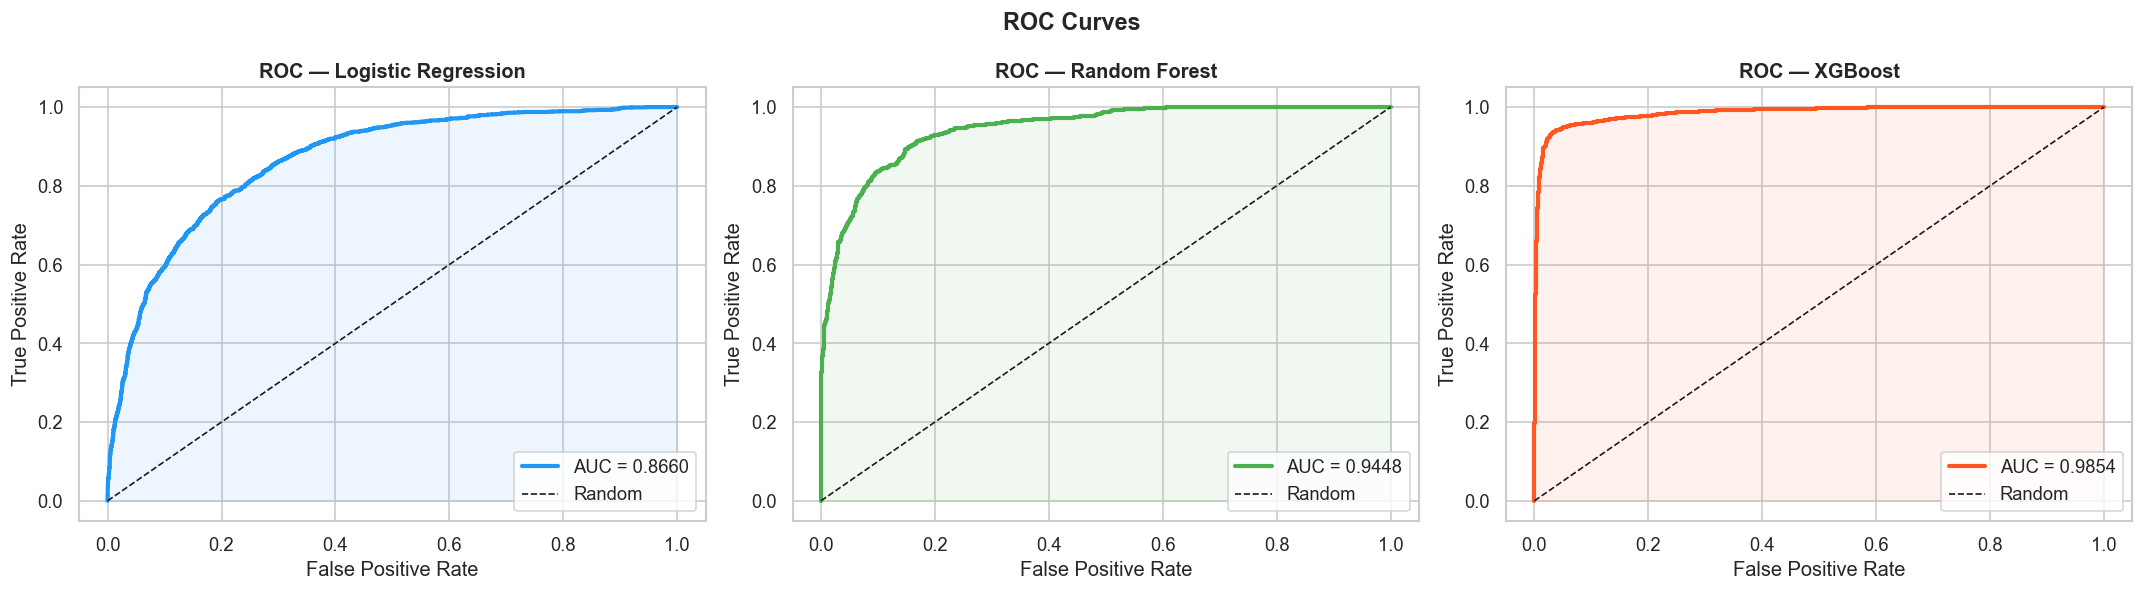

In [24]:
# ---ROC Curves ---
model_specs = [
    ('Logistic Regression', lr_probs,  '#2196F3'),
    ('Random Forest',       rf_probs,  '#4CAF50'),
    ('XGBoost',             xgb_probs, '#FF5722'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, probs, color) in zip(axes, model_specs):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'ROC — {name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
plt.suptitle('ROC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

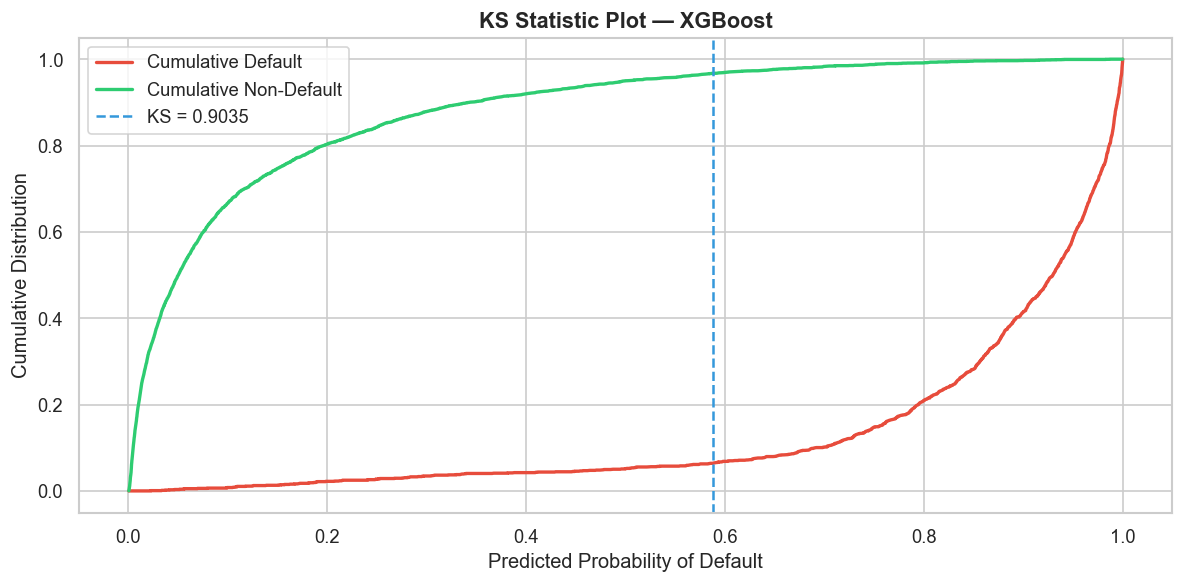

In [25]:
# ---KS Plot ---
def plot_ks(y_true, y_prob, model_name):
    df_ks = pd.DataFrame({'prob': y_prob, 'label': np.array(y_true)}).sort_values('prob').reset_index(drop=True)
    df_ks['cum_default']     = (df_ks['label']==1).cumsum() / (df_ks['label']==1).sum()
    df_ks['cum_non_default'] = (df_ks['label']==0).cumsum() / (df_ks['label']==0).sum()
    df_ks['ks_gap']          = abs(df_ks['cum_default'] - df_ks['cum_non_default'])
    idx = df_ks['ks_gap'].idxmax()

    plt.figure(figsize=(10, 5))
    plt.plot(df_ks['prob'], df_ks['cum_default'],     label='Cumulative Default',     color='#e74c3c', lw=2)
    plt.plot(df_ks['prob'], df_ks['cum_non_default'], label='Cumulative Non-Default', color='#2ecc71', lw=2)
    plt.axvline(df_ks.loc[idx,'prob'], color='#3498db', linestyle='--', lw=1.5,
                label=f'KS = {df_ks.loc[idx,"ks_gap"]:.4f}')
    plt.title(f'KS Statistic Plot — {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Probability of Default')
    plt.ylabel('Cumulative Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ks(y_test.values, xgb_probs, 'XGBoost')

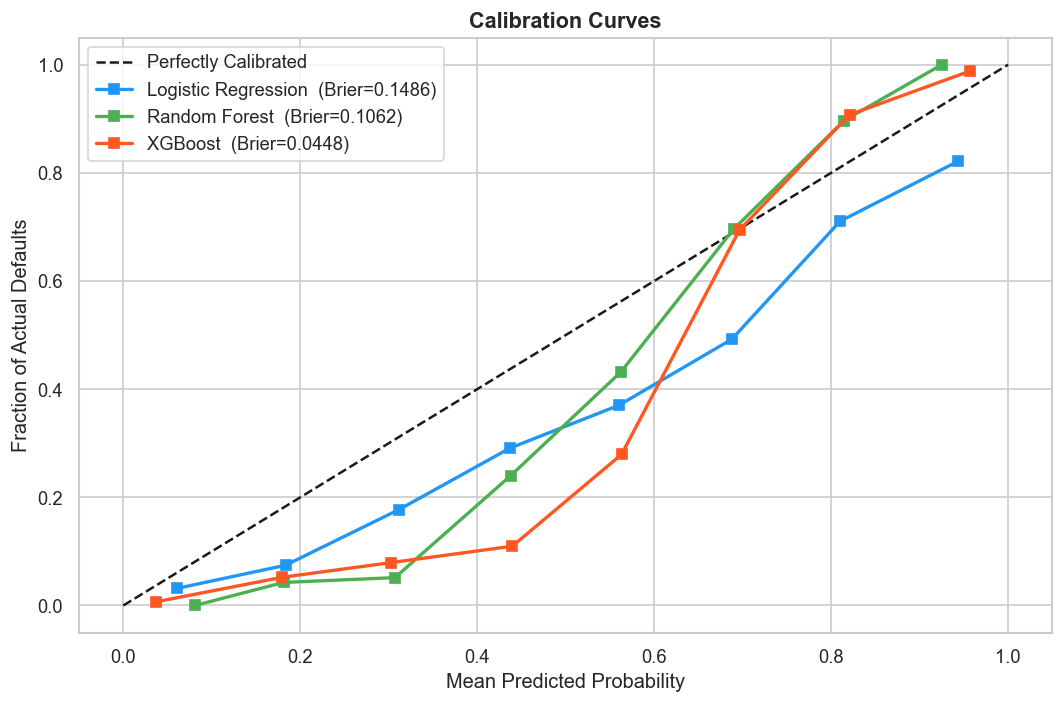

In [26]:
# ---Calibration Curves ---
plt.figure(figsize=(9, 6))
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfectly Calibrated')
for name, probs, color in model_specs:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8)
    plt.plot(mean_pred, frac_pos, 's-', lw=2, color=color,
             label=f'{name}  (Brier={brier_score_loss(y_test,probs):.4f})')
plt.title('Calibration Curves', fontsize=13, fontweight='bold')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Defaults')
plt.legend()
plt.tight_layout()
plt.show()

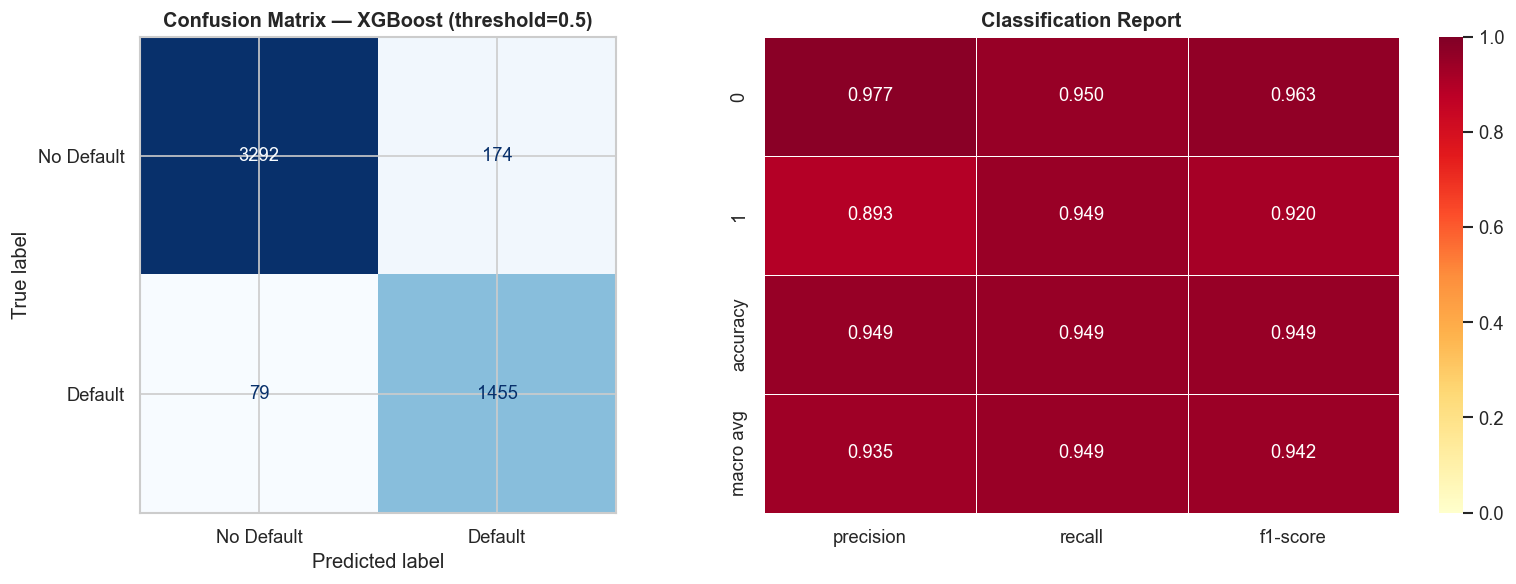

In [27]:
# ---Confusion Matrix + Classification Report ---
THRESHOLD = 0.5
xgb_preds = (xgb_probs >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_preds),
                       display_labels=['No Default','Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — XGBoost (threshold={THRESHOLD})', fontweight='bold')

report_df = pd.DataFrame(classification_report(y_test, xgb_preds, output_dict=True)).T.iloc[:4,:3].astype(float)
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Classification Report', fontweight='bold')
plt.tight_layout()
plt.show()

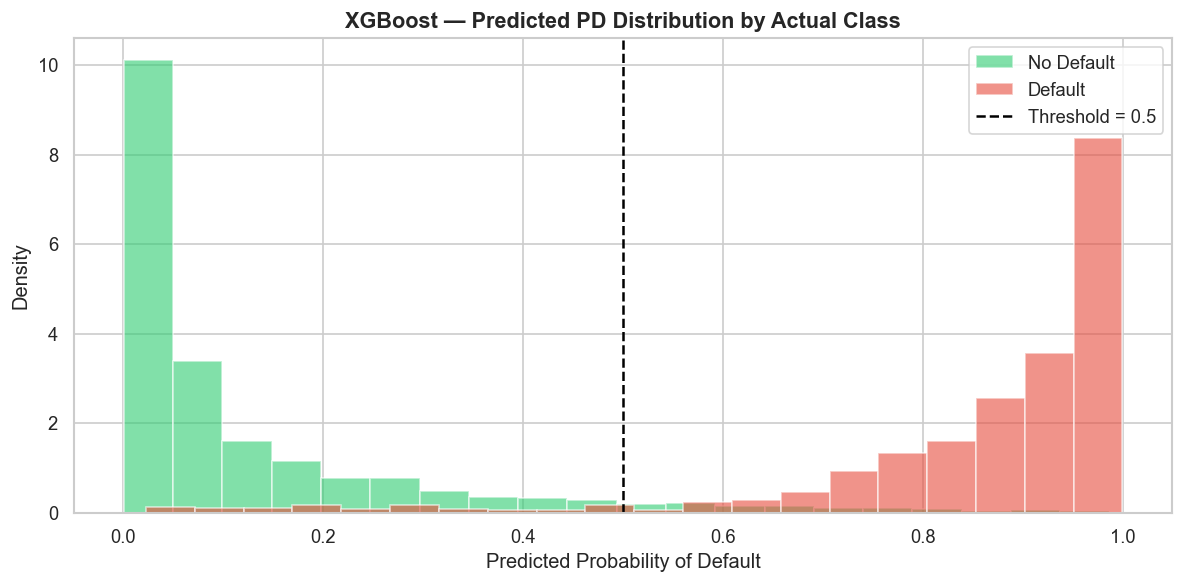

In [28]:
# --- Predicted PD Score Distribution ---
plt.figure(figsize=(10, 5))
for label, color, name in [(0,'#2ecc71','No Default'),(1,'#e74c3c','Default')]:
    plt.hist(xgb_probs[y_test.values==label], bins=20, alpha=0.6,
             color=color, label=name, edgecolor='white', density=True)
plt.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold = {THRESHOLD}')
plt.title('XGBoost — Predicted PD Distribution by Actual Class', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Segment Level Validation
eval_df = X_test.copy().reset_index(drop=True)
eval_df['y_true']   = y_test.values
eval_df['xgb_prob'] = xgb_probs

# Re-attach original labels for readability
orig_test = df.iloc[X_test.index].reset_index(drop=True)
for col in ['Job', 'Housing', 'CheckingStatus', 'CreditHistory', 'Sex']:
    eval_df[col + '_label'] = orig_test[col].values

def segment_auc_table(df_seg, seg_col):
    rows = []
    for seg, grp in df_seg.groupby(seg_col):
        if grp['y_true'].nunique() > 1 and len(grp) >= 5:
            auc = roc_auc_score(grp['y_true'], grp['xgb_prob'])
            rows.append({'Segment': seg, 'Count': len(grp),
                         'Default Rate': f"{grp['y_true'].mean():.1%}",
                         'AUC': round(auc, 4)})
    return pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)

print('=== AUC by Job Type ===')
display(segment_auc_table(eval_df, 'Job_label'))
print('\n=== AUC by Housing ===')
display(segment_auc_table(eval_df, 'Housing_label'))
print('\n=== AUC by Sex ===')
display(segment_auc_table(eval_df, 'Sex_label'))

=== AUC by Job Type ===


,Segment,Count,Default Rate,AUC
0,skilled,3340,31.5%,0.9927
1,unskilled,625,21.6%,0.9756
2,management_self-employed,677,35.3%,0.9725
3,unemployed,358,30.2%,0.9552



=== AUC by Housing ===


,Segment,Count,Default Rate,AUC
0,own,3067,28.8%,0.9869
1,rent,1142,19.2%,0.9837
2,free,791,54.7%,0.9777



=== AUC by Sex ===


,Segment,Count,Default Rate,AUC
0,male,3148,40.6%,0.9854
1,female,1852,13.8%,0.9801


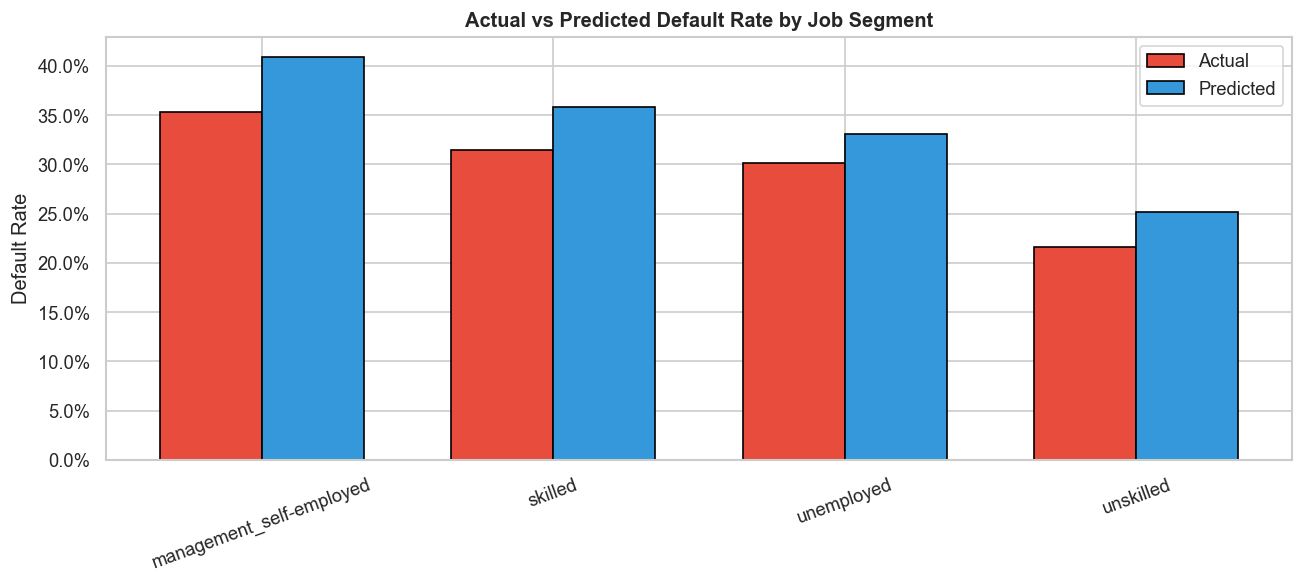

In [30]:
# Actual vs Predicted default rate by Job segment
seg_summary = eval_df.groupby('Job_label').agg(
    Actual    = ('y_true',   'mean'),
    Predicted = ('xgb_prob', 'mean'),
    Count     = ('y_true',   'count')
).reset_index()

x, w = np.arange(len(seg_summary)), 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, seg_summary['Actual'],    w, label='Actual',    color='#e74c3c', edgecolor='black')
ax.bar(x + w/2, seg_summary['Predicted'], w, label='Predicted', color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(seg_summary['Job_label'], rotation=20)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Actual vs Predicted Default Rate by Job Segment', fontweight='bold')
ax.set_ylabel('Default Rate')
ax.legend()
plt.tight_layout()
plt.show()

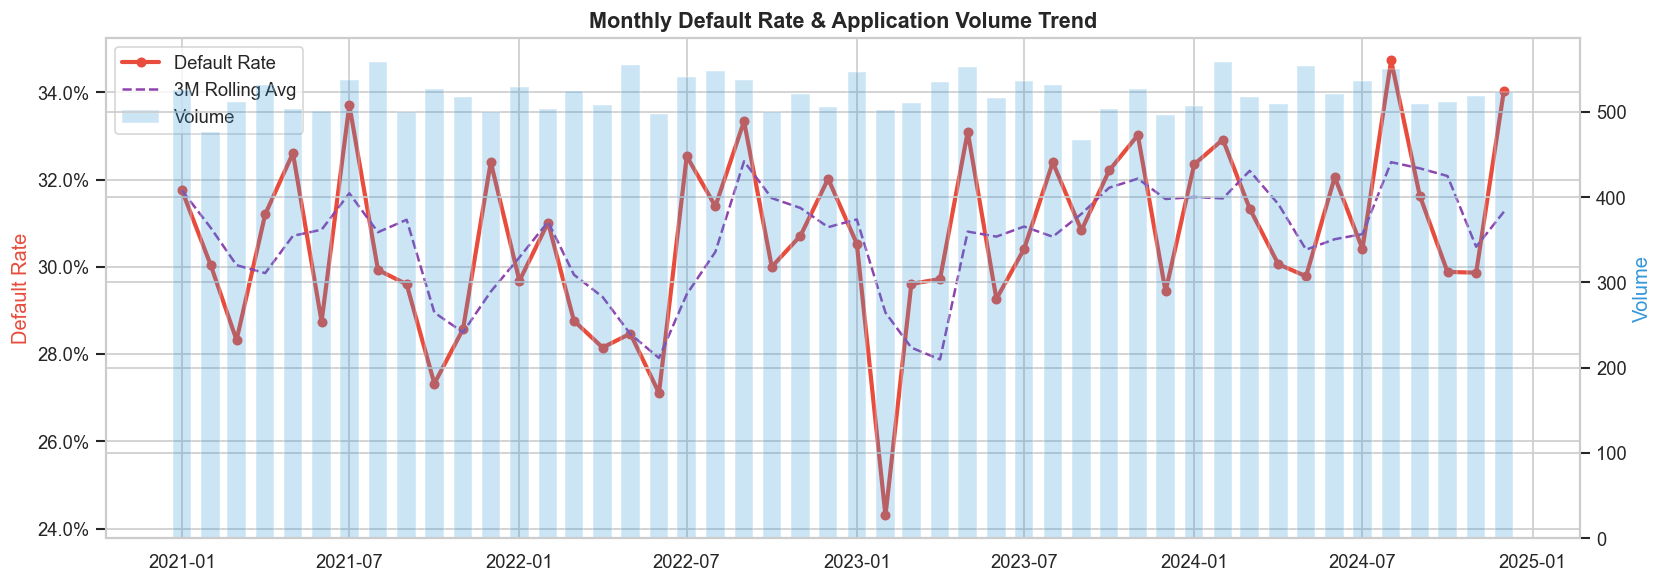

In [31]:
# Time Based Trend Analysis 
time_df = df.copy()
time_df['period'] = pd.to_datetime(
    time_df['application_year'].astype(str) + '-' +
    time_df['application_month'].astype(str).str.zfill(2) + '-01'
)
monthly = (time_df.groupby('period')
           .agg(default_rate=('default','mean'), volume=('default','count'))
           .reset_index().sort_values('period'))
monthly['rolling_avg'] = monthly['default_rate'].rolling(3, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax2.bar(monthly['period'], monthly['volume'], width=20, alpha=0.25, color='#3498db', label='Volume')
ax1.plot(monthly['period'], monthly['default_rate'], color='#e74c3c', lw=2.5, marker='o', ms=5, label='Default Rate')
ax1.plot(monthly['period'], monthly['rolling_avg'],  color='#8e44ad', lw=1.5, linestyle='--', label='3M Rolling Avg')
ax1.set_ylabel('Default Rate', color='#e74c3c')
ax2.set_ylabel('Volume', color='#3498db')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title('Monthly Default Rate & Application Volume Trend', fontsize=13, fontweight='bold')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left')
plt.tight_layout()
plt.show()

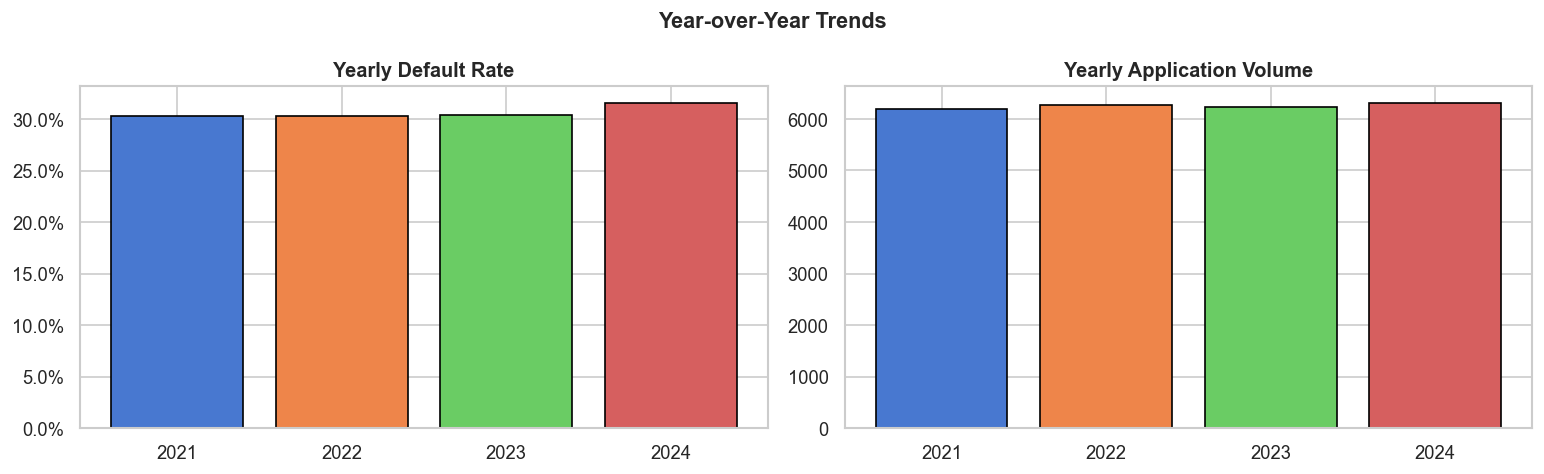

In [32]:
# Yearly comparison
yearly = time_df.groupby('application_year').agg(
    default_rate=('default','mean'), volume=('default','count')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(yearly['application_year'].astype(str), yearly['default_rate'],
            color=sns.color_palette('muted', len(yearly)), edgecolor='black')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Yearly Default Rate', fontweight='bold')

axes[1].bar(yearly['application_year'].astype(str), yearly['volume'],
            color=sns.color_palette('muted', len(yearly)), edgecolor='black')
axes[1].set_title('Yearly Application Volume', fontweight='bold')

plt.suptitle('Year-over-Year Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# SHAP Explainability
# Compute SHAP values
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print(f'✅ SHAP computed | Shape: {shap_values.shape} | Base PD: {explainer.expected_value:.4f}')

✅ SHAP computed | Shape: (5000, 23) | Base PD: 0.0155


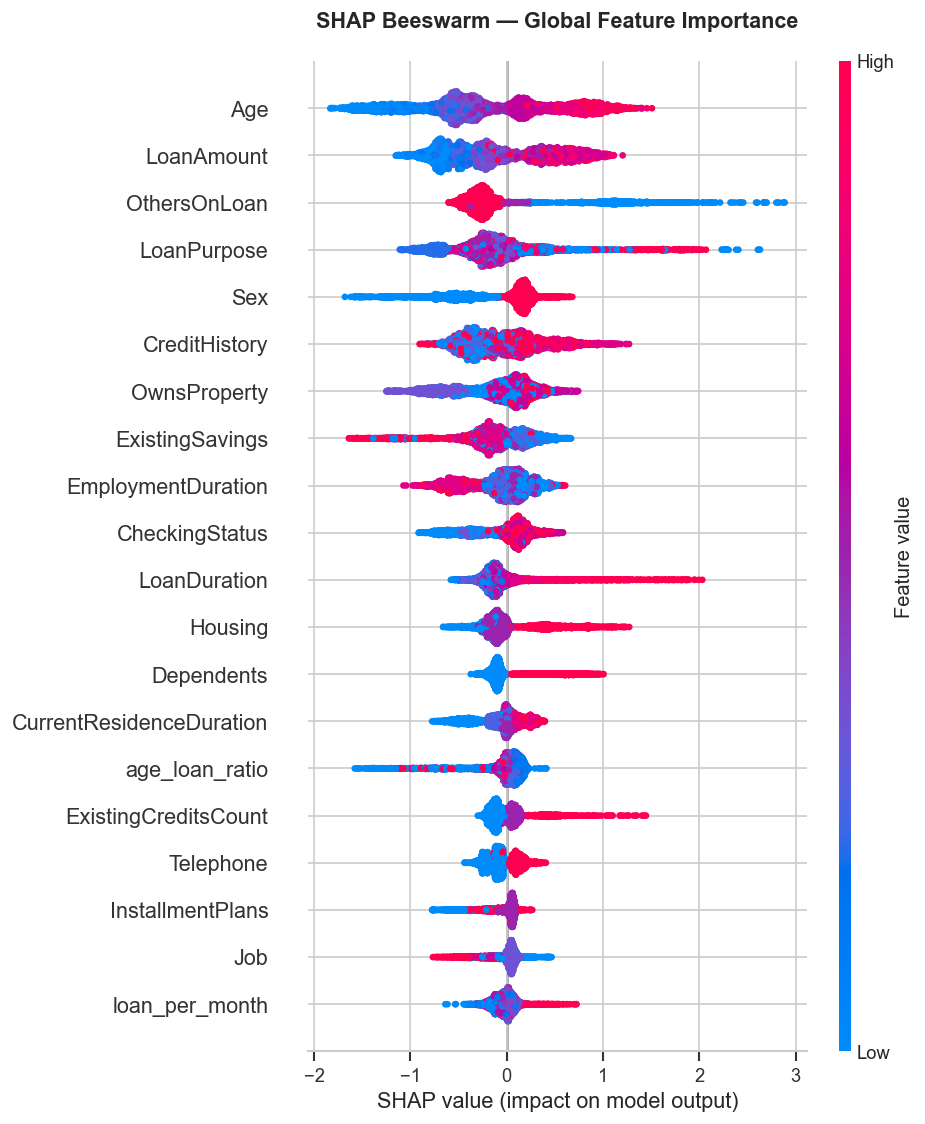

In [34]:
# ---Beeswarm Summary Plot ---
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

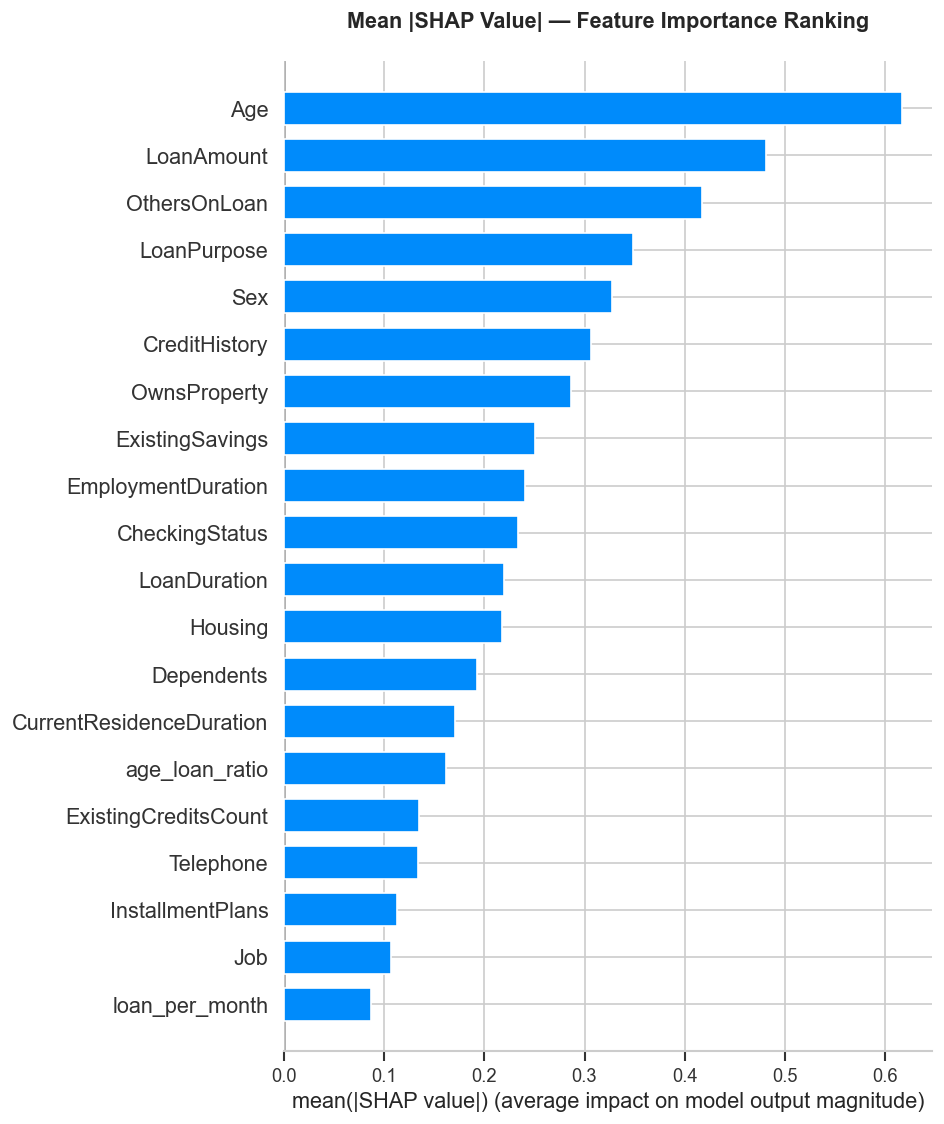

In [35]:
# ---Bar Plot — Mean |SHAP| ---
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type='bar', show=False)
plt.title('Mean |SHAP Value| — Feature Importance Ranking', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

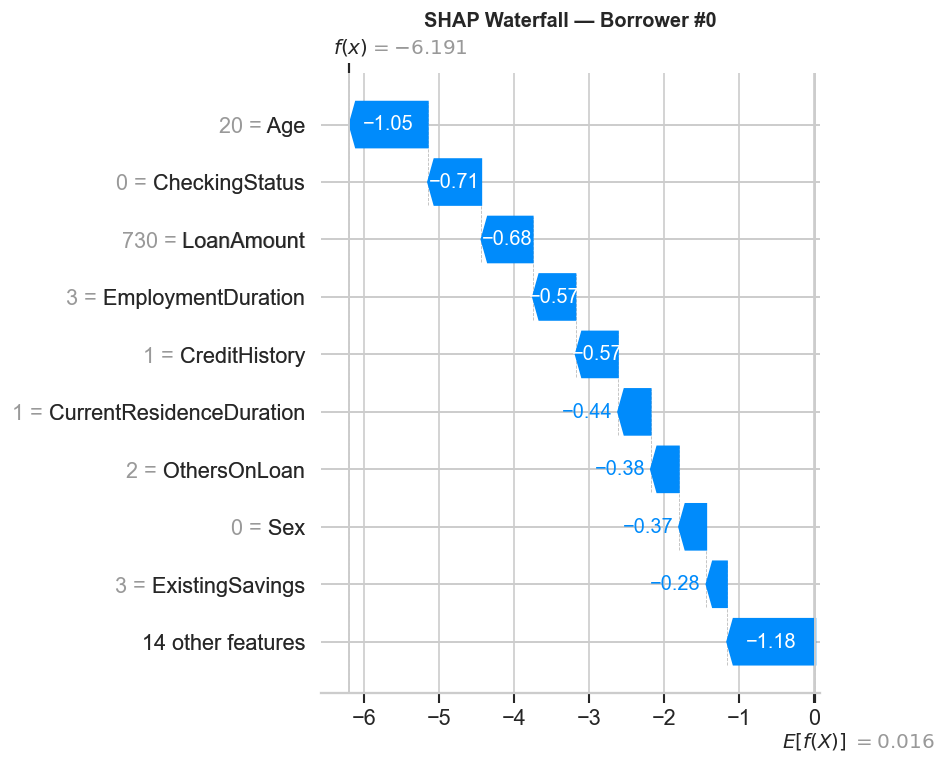

Predicted PD : 0.0020 | Actual: 0


In [36]:
# ---Waterfall — Single Borrower Explanation ---
BORROWER_INDEX = 0   # Change to explain any borrower

shap_exp = shap.Explanation(
    values        = shap_values[BORROWER_INDEX],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[BORROWER_INDEX].values,
    feature_names = FEATURES
)
plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Borrower #{BORROWER_INDEX}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Predicted PD : {xgb_probs[BORROWER_INDEX]:.4f} | Actual: {y_test.iloc[BORROWER_INDEX]}')

<Figure size 1080x600 with 0 Axes>

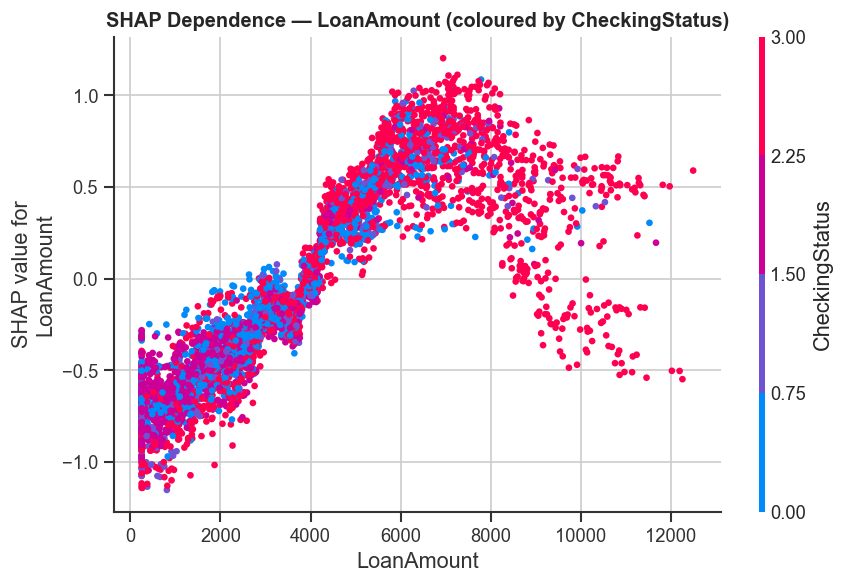

In [37]:
# ---Dependence Plot ---
feat_idx = FEATURES.index('LoanAmount')
int_idx  = FEATURES.index('CheckingStatus')

plt.figure(figsize=(9, 5))
shap.dependence_plot(feat_idx, shap_values, X_test,
                     feature_names=FEATURES, interaction_index=int_idx, show=False)
plt.title('SHAP Dependence — LoanAmount (coloured by CheckingStatus)', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Risk Banding and approval priortization
def assign_risk_band(p):
    if   p < 0.15: return '1 - Low Risk'           # Auto-approve
    elif p < 0.30: return '2 - Medium-Low Risk'    # Approve standard terms
    elif p < 0.50: return '3 - Medium-High Risk'   # Manual review
    else:          return '4 - High Risk'           # Decline

eval_df['risk_band'] = eval_df['xgb_prob'].apply(assign_risk_band)

band_order   = ['1 - Low Risk','2 - Medium-Low Risk','3 - Medium-High Risk','4 - High Risk']
band_summary = (eval_df.groupby('risk_band')
                .agg(Count=('y_true','count'),
                     Default_Rate=('y_true','mean'),
                     Avg_PD=('xgb_prob','mean'),
                     Min_PD=('xgb_prob','min'),
                     Max_PD=('xgb_prob','max'))
                .reindex(band_order).reset_index())
band_summary['Action'] = ['✅ Auto-Approve','🔵 Standard Terms','⚠️ Manual Review','❌ Decline']

display(band_summary)

,risk_band,Count,Default_Rate,Avg_PD,Min_PD,Max_PD,Action
0,1 - Low Risk,2607,0.007672,0.042037,0.001101,0.149921,✅ Auto-Approve
1,2 - Medium-Low Risk,490,0.067347,0.216908,0.150116,0.298944,🔵 Standard Terms
2,3 - Medium-High Risk,274,0.094891,0.390282,0.300129,0.499924,⚠️ Manual Review
3,4 - High Risk,1629,0.893186,0.875461,0.500171,0.999775,❌ Decline


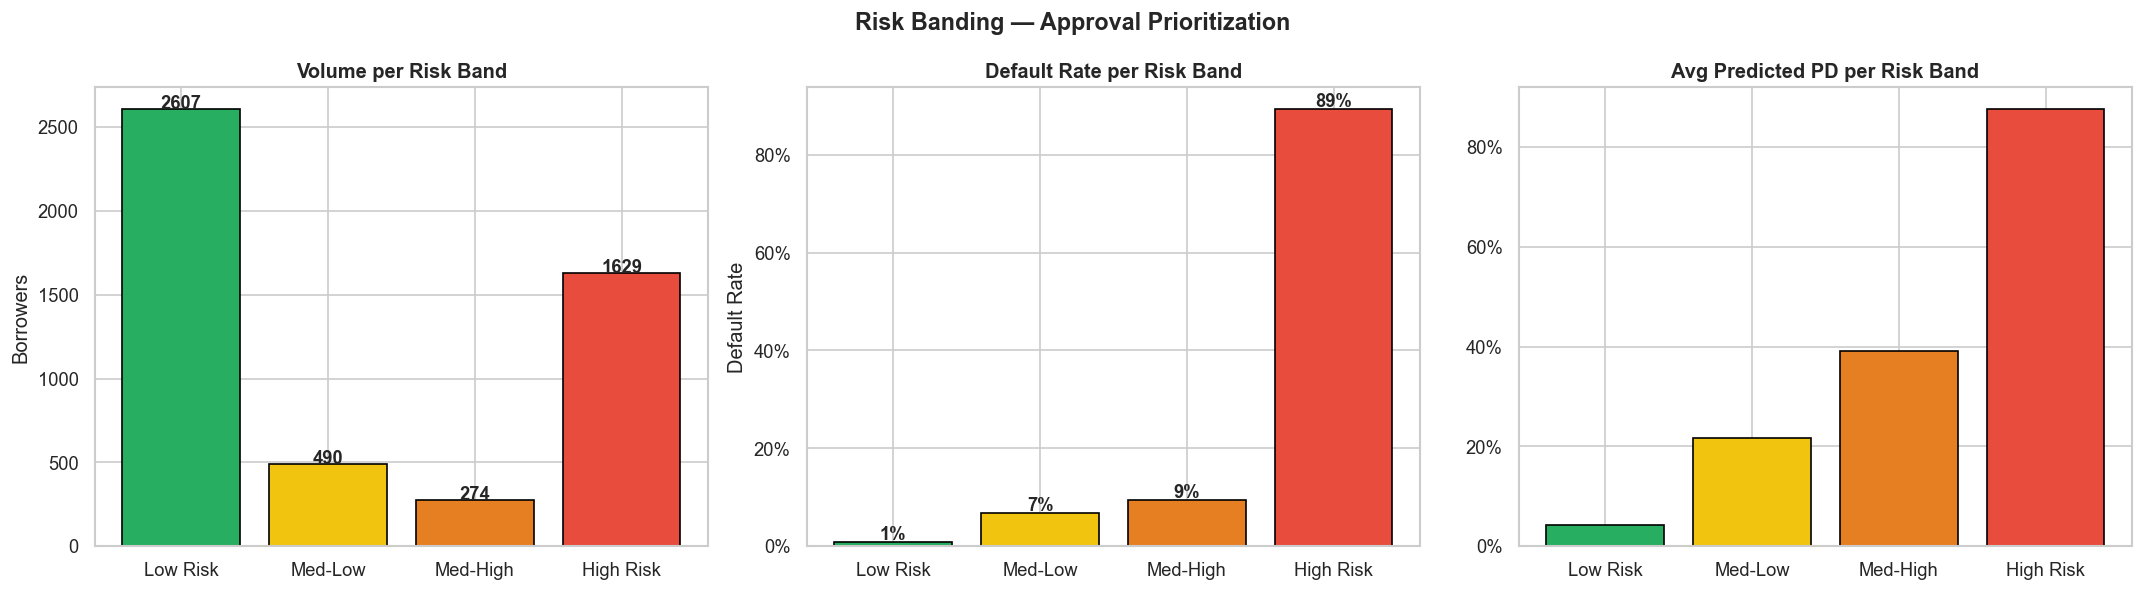

In [39]:
# Risk band charts
colors = ['#27ae60','#f1c40f','#e67e22','#e74c3c']
labels = ['Low Risk','Med-Low','Med-High','High Risk']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(labels, band_summary['Count'], color=colors, edgecolor='black')
axes[0].set_title('Volume per Risk Band', fontweight='bold')
axes[0].set_ylabel('Borrowers')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center', fontweight='bold')

axes[1].bar(labels, band_summary['Default_Rate'], color=colors, edgecolor='black')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('Default Rate per Risk Band', fontweight='bold')
axes[1].set_ylabel('Default Rate')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0%}',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.005), ha='center', fontweight='bold')

axes[2].bar(labels, band_summary['Avg_PD'], color=colors, edgecolor='black')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].set_title('Avg Predicted PD per Risk Band', fontweight='bold')

plt.suptitle('Risk Banding — Approval Prioritization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# FILE 1 — Borrower predictions + risk bands
export_df = df.iloc[X_test.index].copy().reset_index(drop=True)
export_df['predicted_pd_xgb'] = xgb_probs
export_df['predicted_pd_rf']  = rf_probs
export_df['predicted_pd_lr']  = lr_probs
export_df['risk_band']        = eval_df['risk_band'].values
export_df['actual_default']   = y_test.values
export_df.to_csv('01_credit_risk_predictions.csv', index=False)

# FILE 2 — Monthly trend
monthly.to_csv('02_monthly_trend.csv', index=False)

# FILE 3 — Model performance
results_df.to_csv('03_model_performance.csv', index=False)

# FILE 4 — Risk band summary
band_summary.to_csv('04_risk_band_summary.csv', index=False)

# FILE 5 — SHAP feature importance
pd.DataFrame({'Feature': FEATURES,
              'Mean_SHAP': np.abs(shap_values).mean(axis=0)
             }).sort_values('Mean_SHAP', ascending=False).to_csv('05_shap_importance.csv', index=False)

print('All 5 files exported!')
print()
print('Power BI import order:')
print('  01_credit_risk_predictions.csv  → Main fact table')
print('  02_monthly_trend.csv            → Time series line chart')
print('  03_model_performance.csv        → Model comparison bar')
print('  04_risk_band_summary.csv        → KPI cards + donut chart')
print('  05_shap_importance.csv          → Feature importance bar')

All 5 files exported!

Power BI import order:
  01_credit_risk_predictions.csv  → Main fact table
  02_monthly_trend.csv            → Time series line chart
  03_model_performance.csv        → Model comparison bar
  04_risk_band_summary.csv        → KPI cards + donut chart
  05_shap_importance.csv          → Feature importance bar


In [1]:
print(f'Total records: {len(df)}')

NameError: name 'df' is not defined